# Graphical Results
All figures saved to `./results_04_Graphical_Results/`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix

OUT_DIR = r'.\results_04_Graphical_Results'
os.makedirs(OUT_DIR, exist_ok=True)


C_BLUE   = '#2171B5'  
C_ORANGE = '#FD8D3C'   
C_GREEN  = '#74C476'  

# Paths to saved prediction CSVs
XGB_FLOWF_PRED  = r'.\results_03_CrossDomain_RF_XGB_FlowFeatures\XGB\xgb_flowf_predictions.csv'
XGB_SPLT_PRED   = r'.\results_02_CrossDomain_RF_XGB_SPLT\XGB\xgb_predictions.csv'
CNN1D_SPLT_PRED = r'.\results_01_CrossDomain_CNN1D_SPLT\CNN1D\cnn1d_predictions.csv'

# Load predictions
df_xgb_flowf  = pd.read_csv(XGB_FLOWF_PRED)
df_xgb_splt   = pd.read_csv(XGB_SPLT_PRED)
df_cnn1d_splt = pd.read_csv(CNN1D_SPLT_PRED)

print(f'CNN1D SPLT predictions       : {len(df_cnn1d_splt):,} rows | cols: {list(df_cnn1d_splt.columns[:4])}')
print(f'XGB FlowFeatures predictions : {len(df_xgb_flowf):,} rows | cols: {list(df_xgb_flowf.columns[:4])}')
print(f'XGB SPLT predictions         : {len(df_xgb_splt):,} rows | cols: {list(df_xgb_splt.columns[:4])}')

CNN1D SPLT predictions       : 226,314 rows | cols: ['y_true', 'y_pred', 'y_true_name', 'y_pred_name']
XGB FlowFeatures predictions : 226,314 rows | cols: ['y_true', 'y_pred', 'y_true_name', 'y_pred_name']
XGB SPLT predictions         : 226,314 rows | cols: ['y_true', 'y_pred', 'y_true_name', 'y_pred_name']


## Figure 1 " Per-Class F1: Representation -- Model Interaction

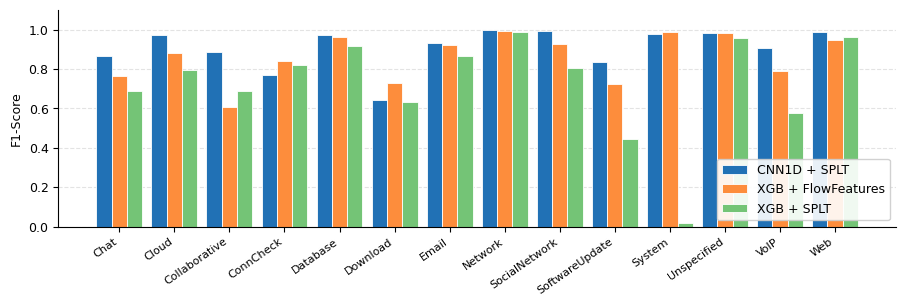

Saved -> .\results_04_Graphical_Results\fig1_per_class_f1_interaction.png
                CNN1D SPLT  XGB FlowFeatures  XGB SPLT  CNN1D - XGB_FlowF  CNN1D - XGB_SPLT
Chat                 0.868             0.764     0.689              0.104             0.179
Cloud                0.973             0.880     0.794              0.093             0.179
Collaborative        0.888             0.607     0.688              0.281             0.200
ConnCheck            0.769             0.842     0.818             -0.073            -0.049
Database             0.972             0.963     0.915              0.009             0.057
Download             0.645             0.727     0.631             -0.082             0.014
Email                0.930             0.923     0.867              0.007             0.063
Network              0.997             0.995     0.988              0.002             0.009
SocialNetwork        0.991             0.929     0.804              0.062             0.187
Softwa

In [2]:
from sklearn.metrics import f1_score

def per_class_f1(df):
    classes = sorted(df['y_true_name'].unique())
    scores = {}
    for cls in classes:
        mask_true = (df['y_true_name'] == cls).values
        mask_pred = (df['y_pred_name'] == cls).values
        tp = (mask_true & mask_pred).sum()
        fp = (~mask_true & mask_pred).sum()
        fn = (mask_true & ~mask_pred).sum()
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        scores[cls] = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return scores

f1_cnn1d_splt = per_class_f1(df_cnn1d_splt)
f1_xgb_flowf  = per_class_f1(df_xgb_flowf)
f1_xgb_splt   = per_class_f1(df_xgb_splt)

classes = sorted(f1_cnn1d_splt.keys())
n = len(classes)
x = np.arange(n) * 1.8
w = 0.50

fig, ax = plt.subplots(figsize=(9, 3))

ax.bar(x - w, [f1_cnn1d_splt[c] for c in classes], w, label='CNN1D + SPLT',       color=C_BLUE,   edgecolor='white', linewidth=0.6)
ax.bar(x,     [f1_xgb_flowf[c]  for c in classes], w, label='XGB + FlowFeatures', color=C_ORANGE, edgecolor='white', linewidth=0.6)
ax.bar(x + w, [f1_xgb_splt[c]   for c in classes], w, label='XGB + SPLT',         color=C_GREEN,  edgecolor='white', linewidth=0.6)


ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=35, ha='right', fontsize=8, fontweight='normal')
ax.set_ylabel('F1-Score', fontsize=9, fontweight='normal')
ax.set_ylim(0, 1.10)
ax.tick_params(axis='y', labelsize=9)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9,
          edgecolor='#cccccc', frameon=True)
ax.yaxis.grid(True, alpha=0.35, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(pad=0.5)

save_path = os.path.join(OUT_DIR, 'fig1_per_class_f1_interaction.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.savefig(save_path.replace('.png', '.pdf'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved ->', save_path)

df_f1 = pd.DataFrame({'CNN1D SPLT':       f1_cnn1d_splt,
                       'XGB FlowFeatures': f1_xgb_flowf,
                       'XGB SPLT':         f1_xgb_splt}).round(3)
df_f1['CNN1D - XGB_FlowF'] = (df_f1['CNN1D SPLT'] - df_f1['XGB FlowFeatures']).round(3)
df_f1['CNN1D - XGB_SPLT']  = (df_f1['CNN1D SPLT'] - df_f1['XGB SPLT']).round(3)
print(df_f1.to_string())


## Figure 2 " Top Confused Category Pairs: CNN1D SPLT Cross-Domain

Top confused pairs -- CNN1D SPLT (Cross-Domain):
True Category Predicted Category  Count  Support  Error Rate (%)
Collaborative                Web    957     6632            14.4
         Chat                Web    616     3985            15.5
     Download               Chat    226      651            34.7
          Web      Collaborative    196   110690             0.2
      Network               VoIP    190    84448             0.2


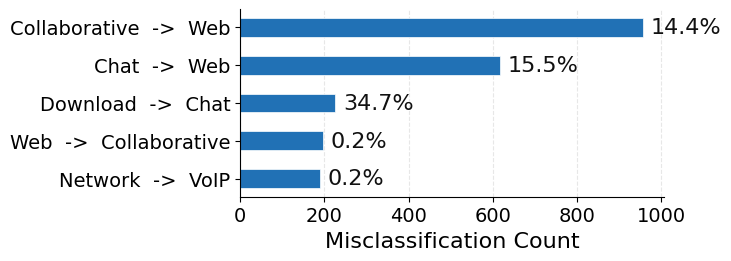

Saved -> .\results_04_Graphical_Results\fig2_top_confused_pairs_bar.pdf


In [7]:
classes_ordered = sorted(df_cnn1d_splt['y_true_name'].unique())

cm = confusion_matrix(df_cnn1d_splt['y_true_name'],
                      df_cnn1d_splt['y_pred_name'],
                      labels=classes_ordered)

pairs = []
for i, true_cls in enumerate(classes_ordered):
    support = cm[i].sum()
    for j, pred_cls in enumerate(classes_ordered):
        if i != j and cm[i, j] > 0:
            pairs.append({
                'True Category':      true_cls,
                'Predicted Category': pred_cls,
                'Count':              int(cm[i, j]),
                'Support':            int(support),
                'Error Rate (%)':     round(100 * cm[i, j] / support, 1),
            })

df_pairs = (pd.DataFrame(pairs)
              .sort_values('Count', ascending=False)
              .reset_index(drop=True))

TOP_N = 5
df_top = df_pairs.head(TOP_N).copy()

print('Top confused pairs -- CNN1D SPLT (Cross-Domain):')
print(df_top[['True Category','Predicted Category','Count','Support','Error Rate (%)']].to_string(index=False))



df_top['Label'] = df_top['True Category'] + '  ->  ' + df_top['Predicted Category']

fig, ax = plt.subplots(figsize=(7.16, 2.5))

bars = ax.barh(df_top['Label'][::-1], df_top['Count'][::-1],
               color=C_BLUE, edgecolor='white', linewidth=0.5,
               height=0.5)

for bar, (_, row) in zip(bars, df_top[::-1].iterrows()):
    ax.text(bar.get_width() + 18, bar.get_y() + bar.get_height() / 2,
            str(row['Error Rate (%)']) + '%',
            va='center', fontsize=16, fontweight='normal', color='#111111')

ax.set_xlabel('Misclassification Count', fontsize=16, fontweight='normal')
ax.xaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

# Make y-tick labels (category pair names) bold
for label in ax.get_yticklabels():
    label.set_fontweight('normal')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(pad=0.3)

save_bar = os.path.join(OUT_DIR, 'fig2_top_confused_pairs_bar.pdf')
plt.savefig(save_bar, dpi=600, bbox_inches='tight')
plt.savefig(save_bar.replace('.pdf', '.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved ->', save_bar)



## Figure 3 "  Precision-Recall curves: Cross-Domain

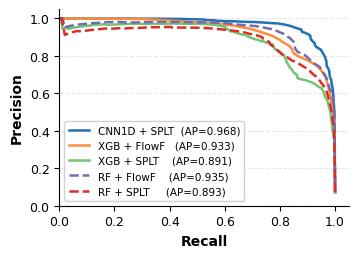

CNN1D  + SPLT  AP: 0.9684
XGB    + FlowF AP: 0.9326
XGB    + SPLT  AP: 0.8912
RF     + FlowF AP: 0.9354
RF     + SPLT  AP: 0.8932


In [8]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

df_rf_flowf = pd.read_csv(r'.\results_03_CrossDomain_RF_XGB_FlowFeatures\RF\rf_flowf_predictions.csv')
df_rf_splt  = pd.read_csv(r'.\results_02_CrossDomain_RF_XGB_SPLT\RF\rf_predictions.csv')

classes = sorted(df_cnn1d_splt['y_true_name'].unique())
n_classes = len(classes)
cls_to_idx = {c: i for i, c in enumerate(classes)}
prob_cols = [f'prob_{c}' for c in classes]

def macro_pr(df):
    y_true_bin = label_binarize(
        [cls_to_idx[c] for c in df['y_true_name']],
        classes=list(range(n_classes))
    )
    prob_matrix = df[prob_cols].values
    mean_recall = np.linspace(0, 1, 500)
    mean_precision = np.zeros_like(mean_recall)
    ap_scores = []
    for i in range(n_classes):
        prec_i, rec_i, _ = precision_recall_curve(y_true_bin[:, i], prob_matrix[:, i])
        ap_scores.append(average_precision_score(y_true_bin[:, i], prob_matrix[:, i]))
        mean_precision += np.interp(mean_recall, rec_i[::-1], prec_i[::-1])
    mean_precision /= n_classes
    return mean_recall, mean_precision, np.mean(ap_scores)

rec_cnn,  prec_cnn,  ap_cnn  = macro_pr(df_cnn1d_splt)
rec_xgbf, prec_xgbf, ap_xgbf = macro_pr(df_xgb_flowf)
rec_xgbs, prec_xgbs, ap_xgbs = macro_pr(df_xgb_splt)
rec_rff,  prec_rff,  ap_rff  = macro_pr(df_rf_flowf)
rec_rfs,  prec_rfs,  ap_rfs  = macro_pr(df_rf_splt)

C_PURPLE = '#756BB1'
C_RED    = '#DE2D26'

fig, ax = plt.subplots(figsize=(3.5, 2.5))

ax.plot(rec_cnn,  prec_cnn,  color=C_BLUE,   lw=1.8, label=f'CNN1D + SPLT  (AP={ap_cnn:.3f})')
ax.plot(rec_xgbf, prec_xgbf, color=C_ORANGE, lw=1.8, label=f'XGB + FlowF   (AP={ap_xgbf:.3f})')
ax.plot(rec_xgbs, prec_xgbs, color=C_GREEN,  lw=1.8, label=f'XGB + SPLT    (AP={ap_xgbs:.3f})')
ax.plot(rec_rff,  prec_rff,  color=C_PURPLE, lw=1.8, label=f'RF + FlowF    (AP={ap_rff:.3f})',  linestyle='--')
ax.plot(rec_rfs,  prec_rfs,  color=C_RED,    lw=1.8, label=f'RF + SPLT     (AP={ap_rfs:.3f})',  linestyle='--')

ax.set_xlabel('Recall', fontsize=10, fontweight='bold')
ax.set_ylabel('Precision', fontsize=10, fontweight='bold')
ax.tick_params(labelsize=9)
ax.legend(fontsize=7.5, loc='lower left', frameon=True,
          edgecolor='#cccccc', framealpha=0.9)
ax.set_xlim([0.0, 1.05])
ax.set_ylim([0.0, 1.05])
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(pad=0.4)

save_path = os.path.join(OUT_DIR, 'fig3_pr_macro_crossdomain.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.savefig(save_path.replace('.png', '.pdf'), dpi=600, bbox_inches='tight')
plt.show()
print(f'CNN1D  + SPLT  AP: {ap_cnn:.4f}')
print(f'XGB    + FlowF AP: {ap_xgbf:.4f}')
print(f'XGB    + SPLT  AP: {ap_xgbs:.4f}')
print(f'RF     + FlowF AP: {ap_rff:.4f}')
print(f'RF     + SPLT  AP: {ap_rfs:.4f}')


## Figure 4a " Confusion Matrix: CNN1D SPLT Cross-Domain

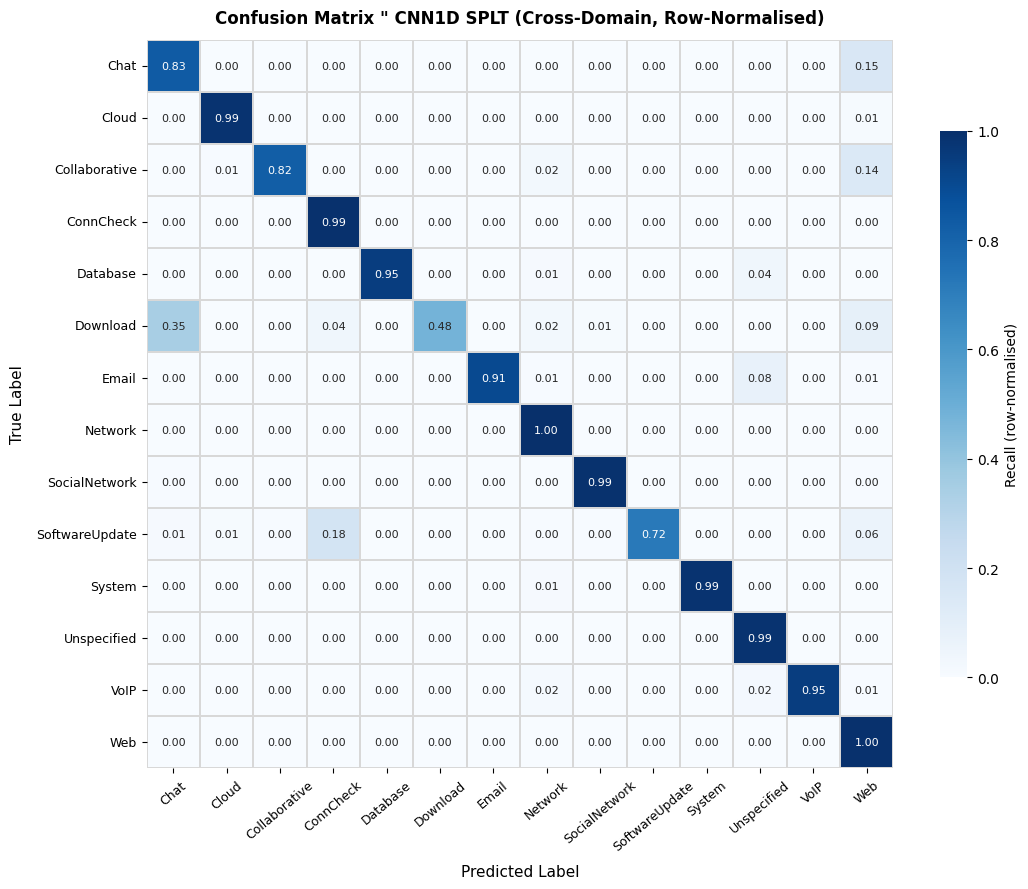

Saved .\results_04_Graphical_Results\fig4a_confusion_matrix_cnn1d_splt.pdf


In [9]:
classes_ordered = sorted(df_cnn1d_splt['y_true_name'].unique())

cm = confusion_matrix(df_cnn1d_splt['y_true_name'],
                      df_cnn1d_splt['y_pred_name'],
                      labels=classes_ordered)

# Row-normalised (recall per class)
cm_norm = cm.astype(float)
row_sums = cm_norm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_norm, row_sums, where=row_sums > 0)

fig, ax = plt.subplots(figsize=(11, 9))
df_cm = pd.DataFrame(cm_norm, index=classes_ordered, columns=classes_ordered)

sns.heatmap(df_cm, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.3, linecolor='#d8d8d8', ax=ax,
            vmin=0, vmax=1,
            cbar_kws={'shrink': 0.75, 'label': 'Recall (row-normalised)'},
            annot_kws={'size': 8})

ax.set_xlabel('Predicted Label', fontsize=11, labelpad=8)
ax.set_ylabel('True Label', fontsize=11, labelpad=8)
ax.set_title('Confusion Matrix " CNN1D SPLT (Cross-Domain, Row-Normalised)',
             fontsize=12, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()

save_path3 = os.path.join(OUT_DIR, 'fig4a_confusion_matrix_cnn1d_splt.pdf')
plt.savefig(save_path3, dpi=300, bbox_inches='tight')
plt.savefig(save_path3.replace('.pdf', '.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {save_path3}')

## Figure 4b " Cross-Model Confusion Comparison: Chat and VoIP

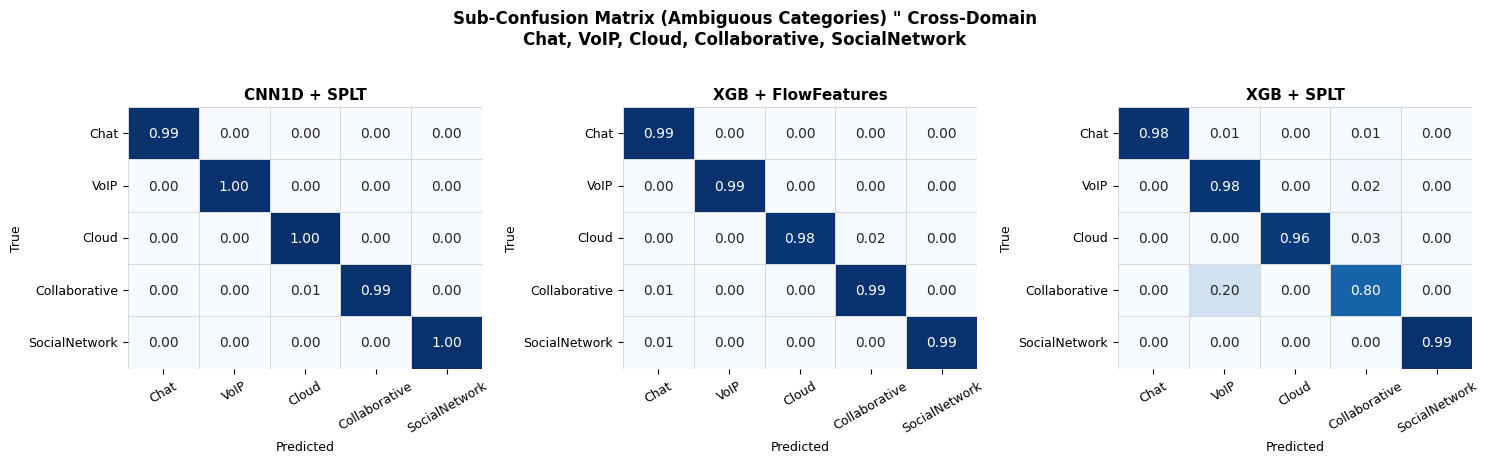

Saved .\results_04_Graphical_Results\fig4b_submatrix_ambiguous_categories.pdf


In [10]:
# Sub-confusion matrix for ambiguous categories across all three models
# All use Blues cmap to keep heatmaps visually unified

focus_classes = ['Chat', 'VoIP', 'Cloud', 'Collaborative', 'SocialNetwork']

def confusion_submatrix(df, focus):
    cm_full = confusion_matrix(df['y_true_name'], df['y_pred_name'], labels=classes_ordered)
    idx = [classes_ordered.index(c) for c in focus]
    sub = cm_full[np.ix_(idx, idx)]
    row_s = sub.sum(axis=1, keepdims=True)
    return np.divide(sub, row_s, where=row_s > 0), focus

sub_cnn1d_splt, labels_sub = confusion_submatrix(df_cnn1d_splt, focus_classes)
sub_xgb_flowf,  _          = confusion_submatrix(df_xgb_flowf,  focus_classes)
sub_xgb_splt,   _          = confusion_submatrix(df_xgb_splt,   focus_classes)

# Order matches bar chart: CNN1D first, then XGB FlowF, then XGB SPLT
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
titles = ['CNN1D + SPLT', 'XGB + FlowFeatures', 'XGB + SPLT']
mats   = [sub_cnn1d_splt, sub_xgb_flowf, sub_xgb_splt]

for ax, mat, title in zip(axes, mats, titles):
    df_sub = pd.DataFrame(mat, index=labels_sub, columns=labels_sub)
    sns.heatmap(df_sub, annot=True, fmt='.2f', cmap='Blues',
                vmin=0, vmax=1, ax=ax,
                linewidths=0.4, linecolor='#d8d8d8',
                cbar=False, annot_kws={'size': 10})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.suptitle('Sub-Confusion Matrix (Ambiguous Categories) " Cross-Domain\n'
             'Chat, VoIP, Cloud, Collaborative, SocialNetwork',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()

save_path4 = os.path.join(OUT_DIR, 'fig4b_submatrix_ambiguous_categories.pdf')
plt.savefig(save_path4, dpi=300, bbox_inches='tight')
plt.savefig(save_path4.replace('.pdf', '.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {save_path4}')

### fig5_union_confused_submatrix

CNN1D top confused : ['Chat', 'Collaborative', 'Download', 'Network', 'SoftwareUpdate', 'Web']
XGB FlowF top confused: ['Chat', 'Cloud', 'Collaborative', 'Network', 'VoIP', 'Web']
XGB SPLT  top confused: ['Chat', 'Cloud', 'Collaborative', 'SocialNetwork', 'SoftwareUpdate', 'System']

Union (10 categories): ['Chat', 'Cloud', 'Collaborative', 'Download', 'Network', 'SocialNetwork', 'SoftwareUpdate', 'System', 'VoIP', 'Web']


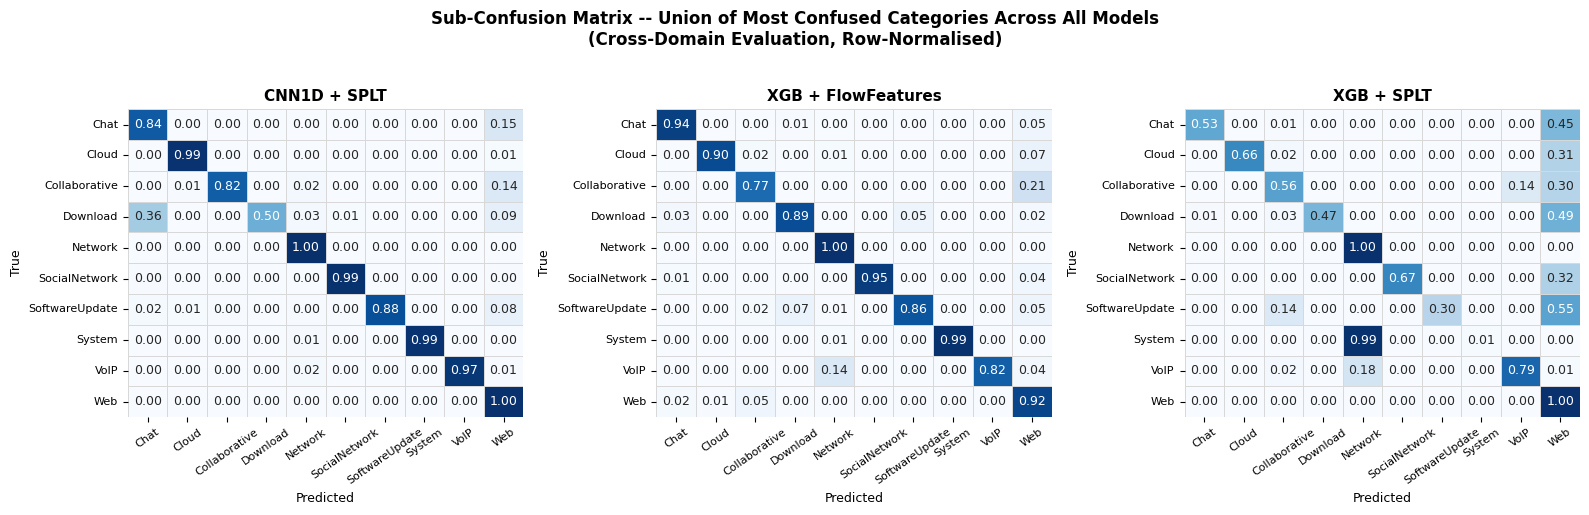

Saved -> .\results_04_Graphical_Results\fig5_union_confused_submatrix.pdf


In [11]:
# --- Figure 5: Sub-confusion matrix using union of top confused categories across all 3 models ---
# For each model, find its top-N most confused categories (by total misclassification count).
# Take the union -> fixed category set that represents hard cases for at least one model.

TOP_CATS = 6  # number of top confused categories to take from each model

def top_confused_categories(df, n):
    """Return the n categories with the highest total misclassification count."""
    wrong = df[df['y_true_name'] != df['y_pred_name']]
    counts = wrong.groupby('y_true_name').size().sort_values(ascending=False)
    return set(counts.head(n).index.tolist())

cats_cnn1d = top_confused_categories(df_cnn1d_splt, TOP_CATS)
cats_flowf = top_confused_categories(df_xgb_flowf,  TOP_CATS)
cats_splt  = top_confused_categories(df_xgb_splt,   TOP_CATS)

union_cats = sorted(cats_cnn1d | cats_flowf | cats_splt)
print(f'CNN1D top confused : {sorted(cats_cnn1d)}')
print(f'XGB FlowF top confused: {sorted(cats_flowf)}')
print(f'XGB SPLT  top confused: {sorted(cats_splt)}')
print(f'\nUnion ({len(union_cats)} categories): {union_cats}')

def confusion_submatrix(df, focus):
    cm_full = confusion_matrix(df['y_true_name'], df['y_pred_name'], labels=classes_ordered)
    idx = [classes_ordered.index(c) for c in focus]
    sub = cm_full[np.ix_(idx, idx)]
    row_s = sub.sum(axis=1, keepdims=True)
    return np.divide(sub, row_s, where=row_s > 0)

sub_cnn1d = confusion_submatrix(df_cnn1d_splt, union_cats)
sub_flowf = confusion_submatrix(df_xgb_flowf,  union_cats)
sub_splt  = confusion_submatrix(df_xgb_splt,   union_cats)

# Order: CNN1D first (matches bar chart order)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['CNN1D + SPLT', 'XGB + FlowFeatures', 'XGB + SPLT']
mats   = [sub_cnn1d, sub_flowf, sub_splt]

for ax, mat, title in zip(axes, mats, titles):
    df_sub = pd.DataFrame(mat, index=union_cats, columns=union_cats)
    sns.heatmap(df_sub, annot=True, fmt='.2f', cmap='Blues',
                vmin=0, vmax=1, ax=ax,
                linewidths=0.4, linecolor='#d8d8d8',
                cbar=False, annot_kws={'size': 9})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle(
    'Sub-Confusion Matrix -- Union of Most Confused Categories Across All Models\n'
    '(Cross-Domain Evaluation, Row-Normalised)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()

save_path5 = os.path.join(OUT_DIR, 'fig5_union_confused_submatrix.pdf')
plt.savefig(save_path5, dpi=300, bbox_inches='tight')
plt.savefig(save_path5.replace('.pdf', '.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved ->', save_path5)
